In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
# Шаг 1. Загрузка данных и моделей
with open('code_corpus.json', encoding='utf-8') as f:
    code_corpus = json.load(f)
with open('eval_questions.json', encoding='utf-8') as f:
    eval_questions = json.load(f)
with open('categories.json', encoding='utf-8') as f:
    categories = json.load(f)

# Сколько загрузилось
print(f"Загружено {len(code_corpus)} фрагментов кода")
print(f"Загружено {len(eval_questions)} вопросов")
print(f"Загружено {len(categories['categories'])} категорий")

# Объединение
text_corpus = []
for text in code_corpus:
    full_text = text['code'] + text['description']
    text_corpus.append(full_text)

questions = [q['query'] for q in eval_questions]
correct_ids = [q['correct_chunk_id'] for q in eval_questions]

# Проверка, что всё ок
print(f"Проверка: {text_corpus[0][:130]}")


Загружено 200 фрагментов кода
Загружено 25 вопросов
Загружено 5 категорий
Проверка: def verify_jwt_token(token: str, secret: str) -> dict:
    """Проверяет JWT-токен и возвращает payload или причину невалидности.""


In [9]:
# Шаг 2. Генерация эмбеддингов и поиск

models_list = ["paraphrase-multilingual-MiniLM-L12-v2",
               "paraphrase-multilingual-mpnet-base-v2",
               "intfloat/multilingual-e5-small"
]

# Загрузка моделей
loaded_models = {}
for model_name in models_list:
    print(f"Модель {model_name}")
    loaded_models[model_name] = SentenceTransformer(model_name)

print("")

embeddings = {}
for name, model in loaded_models.items():
    print(name)
    embeddings[name] = model.encode(text_corpus, show_progress_bar=True, batch_size=32)
    print(f"{name} Полученная матрица: {embeddings[name].shape}")


# Поиск
def search(query, model, embeddings):
    query_embedding = model.encode([query])
    cos_similarity = cosine_similarity(query_embedding, embeddings)[0]
    top_3 = np.argsort(cos_similarity)[::-1][:3]
    return top_3, cos_similarity[top_3]

# ID всех фрагментов кода
corpus_ids = [item['id'] for item in code_corpus]
corpus_categories = [item['category'] for item in code_corpus]
query_languages = [q['language'] for q in eval_questions]

print("")

print(f"corpus_ids создано: {len(corpus_ids)} штук")
print(f"категории: {len(set(corpus_categories))} уникальных")

Модель paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модель paraphrase-multilingual-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модель intfloat/multilingual-e5-small


...

paraphrase-multilingual-MiniLM-L12-v2 Полученная матрица: (200, 384)
paraphrase-multilingual-mpnet-base-v2


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

paraphrase-multilingual-mpnet-base-v2 Полученная матрица: (200, 768)
intfloat/multilingual-e5-small


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

intfloat/multilingual-e5-small Полученная матрица: (200, 384)

corpus_ids создано: 200 штук
категории: 5 уникальных



paraphrase-multilingual-MiniLM-L12-v2]
Precision@3 = 72.00% (18/25)

paraphrase-multilingual-mpnet-base-v2]
Precision@3 = 84.00% (21/25)

intfloat/multilingual-e5-small]
Precision@3 = 92.00% (23/25)
                               Модель Precision@3
paraphrase-multilingual-MiniLM-L12-v2      72.00%
paraphrase-multilingual-mpnet-base-v2      84.00%
       intfloat/multilingual-e5-small      92.00%


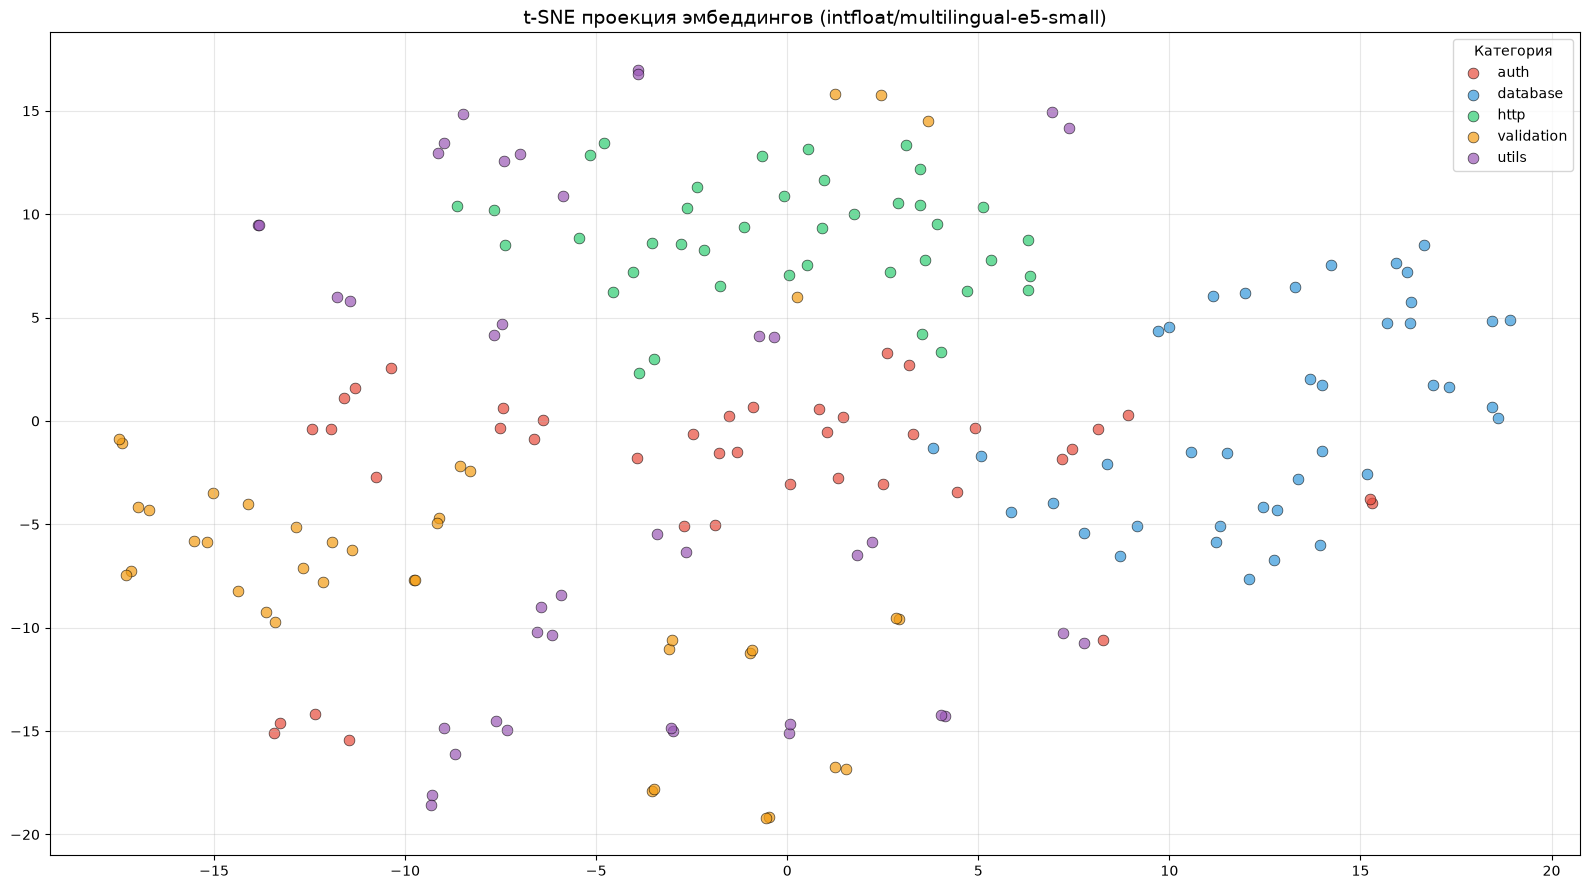

In [8]:
# Шаг 3. Метрика и визуализация
result = {}

for name, model in loaded_models.items():
    print(f"\n{name}]")
    result[name] = []
    correct = 0

    for i in range(len(questions)):
        query = questions[i]
        top_3, top_scores = search(query, model, embeddings[name])
        found_ids = [corpus_ids[j] for j in top_3]
        is_correct = correct_ids[i] in found_ids
        correct += is_correct
        result[name].append({
            'query': query,
            'found': found_ids,
            'is_correct': is_correct
        })

    print(f"Precision@3 = {correct/len(questions):.2%} ({correct}/{len(questions)})")

# Таблица
data = [[name, f"{sum(1 for r in result[name] if r['is_correct'])/len(questions):.2%}"] for name in result]
print(pd.DataFrame(data, columns=['Модель', 'Precision@3']).to_string(index=False))

# Считает кол-во верных ответов для каждой модели
scores = {}
for name in loaded_models:
    scores[name] = sum(1 for r in result[name] if r['is_correct'])

# Записывает модель с max числом верных ответов
best_model = max(scores, key=scores.get)
best_embeddings = embeddings[best_model]

# Цвета
category_colors = {}
for c in categories['categories']:
    category_colors[c['key']] = c['color']

# Проекция
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
cords = tsne.fit_transform(best_embeddings)

# График
fig, ax = plt.subplots(figsize=(16, 9))

for category, color in category_colors.items():
    mask = [c == category for c in corpus_categories]
    ax.scatter(
        cords[mask, 0],
        cords[mask, 1],
        c = color,
        label = category,
        alpha = 0.7,
        s = 60,
        edgecolors = 'black',
        linewidth = 0.5
    )

ax.set_title(f"t-SNE проекция эмбеддингов ({best_model})", fontsize=14)
ax.legend(title="Категория", loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1-я модель выбрана как лёгкий и быстрый вариант. Малогабаритная и хорошо подходит для базового тестирования. Она позволяет оценить минимальный уровень качества, который можно получить с минимальными затратами ресурсов.
2-я модель тяжелее чем 1-я, но будет точнее т.к. размерность в 2 раза больше. Её цель просто показать, что можно выиграть за счёт качества если пожертвовать скоростью. Долгое время считался одним из лучших многоязычных решений.
3-я модель выбрана потому что она новее. У неё размерность такая же как и у 1-ой, но она более прокаченная под поиск на огромных данных. Также загрузка идет быстрее чем у других моделей, которые будут лучше, чем mpnet.
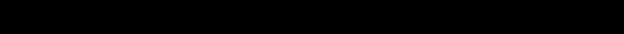
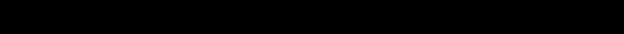